<div style="border-left:4px solid #3D6FB0;padding:6px 0 8px 16px;"><div style="opacity:.72;font-size:12px;letter-spacing:1.4px;">Datos Masivos II · PRÁCTICA 1</div><div style="color:#3D6FB0;font-size:27px;font-weight:700;margin-top:4px;">Sección Dos: Hojas de Tomate</div><div style="opacity:.72;font-size:14px;margin-top:6px;margin-bottom:10px;">Equipo Tres: Castrillo Cruz Karen Arlet, Ramos González Nadia, Zamora Antiga Ángel Javier.</div><img src="https://mmss.iimas.unam.mx/dmmss/wp-content/uploads/2026/02/cropped-LogoUNAM_IIMAS_Negro50-scaled-2.png" width="200"/></div>

## Instrucciones 
Realizar una comparación entre: PCA, Non Negative Matrix y TSNE con los conjuntos de datos dados, así como una visualización de estos. 
Además, generar un clasificador o identificación de patrones, según sea el caso.

<div style="border-left:4px solid #524e64;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="color:#3D6FB0;font-size:21px;font-weight:700;">0. Contexto. Clasificación de Hojas de Tomate: Identificación de infecciones en huerta. </span></div>

La presencia de plagas en u otras enfermedades en huertos puede llegar a tener un impacto significativo en producción y calidad, que se ve reflejado en un desabasto de alimentos para una pobolación. En búsqueda de solucionar esta problemática, utilizaremos la base de datos proporcionada, que se divide en dos conjuntos de datos de imágenes de hojas de tomate según diferentes fuentes. Las imágenes de hojas de tomate del primer conjunto de datos se seleccionaron de la base de datos `PlantVillage` con diez categorías (nueve categorías de **enfermedades** y una de **salud**). Las categorías detalladas del primer conjunto de datos son:
1. Mancha bacteriana,
2. Tizón temprano,
3. Saludable,
4. Tizón tardío,
5. Moho foliar,
6. Mancha foliar por Septoria,
7. Mancha diana,
8. Virus del mosaico del tomate,
9. Virus del rizado amarillo de la hoja del tomate,
10. Araña de dos manchas

El segundo conjunto de datos son imágenes de hojas de tomate de Taiwán, con seis categorías (cinco de **enfermedades** y una de **salud**). Incluye imágenes de una sola hoja, varias hojas, un fondo simple y un fondo complejo, con registros sintéticos creados a través de un método de aumento de datos para incrementar el número de imágenes. Tras la mejora de datos, se obtuvieron 4976 imágenes. Las categorías detalladas del segundo conjunto de datos son:
1. Mancha bacteriana,
2. Moho negro de la hoja,
3. Mancha gris de la hoja,
4. Sano,
5. Tizón tardío,
6. Oídio

Al realizar un aplanado, se obtienen instancias con **51,529 dimensiones**, que hace poco eficiente analizar una gran cantidad de información. Por ende, para facilitar la detección oportuna de enfermedades, se implementarán los algoritmos de reducción de dimensionalidad vistos en clase para disminuir la cantidad de atributos y se evaluará un clasificador para verificar la efectividad de la reducción.

<div style="border-left:4px solid #524e64;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="color:#3D6FB0;font-size:21px;font-weight:700;">0.1 Los Datos </span></div>

* `plant_village`: Conjunto de datos que cuenta con las 10 categorías originales en imágenes de dimensión $227\times227$. Contiene dos carpetas: `5 cross-validation`, con las imágenes ya divididas para validación cruzada de 5 pliegues, y `Preprocessed data`, con las imágenes preprocesadas antes de la división.
* `taiwan`: Conjunto con 6 categorías, de 662 imágenes originales (presentes y divididas en `Preprocessed data`) y 4976 totales (tras generar datos sintéticos, presentes y divididas en `data augmentation`).

<div style="border-left:4px solid #524e64;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="color:#3D6FB0;font-size:21px;font-weight:700;">0.2 Preparación de Entorno  </span></div>

In [1]:
# Importación de Bibliotecas

# Rutas y acceso a carpetas
import os
from pathlib import Path

# Manejo de datos
import pandas as pd
import numpy as np
import re
import math as mt

# Visualización
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import seaborn as sns
import plotly.express as px

# Extracción de características
from skimage.feature import local_binary_pattern

# Escalado y separación
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV

# Reducción de dimensionalidad
from sklearn.decomposition import PCA, NMF
from sklearn.manifold import TSNE

# Aprendizaje de máquinas
from sklearn.svm import SVC

#Evaluación
from sklearn.metrics import classification_report

In [2]:
def perfilar_dataset_imagenes(ruta_base):
    """ 
    Función que escanea los archivos y devuelve un resumen en metadatos de todas las imágenes dentro del repositorio.

    Args:
        ruta_base (str): Dirección de la carpeta donde están presentes las imágenes.

    Returns:
        df_meta (pd.DataFrame): DataFrame con información general de las imágenes, como tamaño, etiqueta, peso, ruta
                                completa, etcétera.
    """
    metadatos = []
    ruta_path = Path(ruta_base)
    extensiones_validas = {'.jpg', '.jpeg', '.png', '.bmp'}
    
    for ruta_img in ruta_path.rglob('*'):
        if ruta_img.suffix.lower() in extensiones_validas:
            categoria = ruta_img.parent.name
            try:
                with Image.open(ruta_img) as img:
                    ancho, alto = img.size
                    modo = img.mode
                    canales = len(img.getbands())
                    peso_kb = os.path.getsize(ruta_img) / 1024 # División para convertir
                    
                    metadatos.append({
                        'archivo': ruta_img.name,
                        'categoria': categoria,
                        'ancho': ancho,
                        'alto': alto,
                        'canales': canales,
                        'modo': modo,
                        'peso_kb': peso_kb,
                        'ruta': str(ruta_img),
                        'corrupta': False
                    })
            except Exception as e:
                metadatos.append({
                    'archivo': ruta_img.name,
                    'categoria': categoria,
                    'ruta': str(ruta_img),
                    'corrupta': True,
                    'error': str(e)
                })
                
    df_meta = pd.DataFrame(metadatos)
    
    # Impresión del diagnóstico
    print("=" * 50)
    print("DIAGNÓSTICO GENERAL DEL DATASET DE IMÁGENES")
    print("=" * 50)
    print(f"Total de imágenes detectadas: {len(df_meta)}")
    print(f"Imágenes corruptas: {df_meta['corrupta'].sum()}")
    
    print("\n--- Distribución por Categoría ---")
    print(df_meta['categoria'].value_counts())
    
    print("\n--- Resoluciones/Dimensiones Detectadas ---")
    print(df_meta[['ancho', 'alto', 'canales', 'modo']].drop_duplicates().to_string(index=False))
    
    return df_meta

In [3]:
def mostrar_grid_por_clase(df_meta, cols=4):
    """
    Función que muestra una cuadrícula con 1 imagen representativa de cada clase.

    Args:
        df_meta (pd.DataFrame): DataFrame con metadatos de las imágenes presentes en las carpetas.
        cols (int -  default 5): Columnas que tendrá la gráfica de representaciones
    
    Returns:
        None: Muestra la cuadrícula, no retorna valores.
    """
    df_validas = df_meta[~df_meta['corrupta']]
    clases = df_validas['categoria'].unique()
    filas = (len(clases) + cols - 1) // cols
    
    fig, axes = plt.subplots(filas, cols, figsize=(cols * 3.5, filas * 3.5))
    axes = axes.flatten()
    
    for i, clase in enumerate(clases):
        sub_df = df_validas[df_validas['categoria'] == clase]
        ruta_img = sub_df.iloc[0]['ruta']
        img = Image.open(ruta_img)
        
        axes[i].imshow(img)
        axes[i].set_title(f"{clase}\n{img.size[0]}x{img.size[1]} px", fontsize=9)
        axes[i].axis('off')
        
    # Ocultar subplots vacíos si la cuadrícula es mayor al número de clases
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

In [4]:
def resumir_categorias_dataset(base_dir):
    """ 
    Función que recorre los archivos para realizar un conteo de imágenes por procesamiento, entreno/prueba y split (donde se de el caso)

    Args:
        base_dir (str):  Dirección de los archivos a resumir

    Returns:
        df_resumen (pd.DataFrame): Dataframe de resumen/conteo con columnas ordenadas para facilitar visualización
    """
    extensiones = {'.jpg', '.jpeg', '.png', '.bmp', '.JPG', '.PNG', '.JPEG'}
    registros = []
    base_path = Path(base_dir)

    # Recorrer de forma recursiva todos los archivos de imagen
    for filepath in base_path.rglob('*'):
        if filepath.suffix in extensiones:
            # Convertir partes de la ruta a minúsculas para comparaciones robustas
            partes_ruta = [p.lower() for p in filepath.parts]
            
            # Categoría: nombre de la carpeta contenedora inmediata
            categoria = filepath.parent.name
            
            # Identificar si está en carpeta preprocesada
            es_preprocesado = any('preprocessed' in p for p in partes_ruta)
            
            # Identificar el conjunto Split
            if 'train' in partes_ruta:
                split = 'Train'
            elif 'test' in partes_ruta:
                split = 'Test'
            else:
                split = 'Sin Split'

            registros.append({
                'Categoria': categoria,
                'Preprocesado': 'Preprocesada' if es_preprocesado else 'No Preprocesada',
                'Split': split
            })

    df = pd.DataFrame(registros)

    if df.empty:
        print("No se encontraron imágenes en el directorio indicado.")
        return None

    # Crear tablas cruzadas para Preprocesamiento y Split
    df_pre = pd.crosstab(df['Categoria'], df['Preprocesado'])
    df_split = pd.crosstab(df['Categoria'], df['Split'])
    df_total = df.groupby('Categoria').size().to_frame(name='Total_Imagenes')

    # Unir todo en una sola vista estructurada
    df_resumen = pd.concat([df_pre, df_split, df_total], axis=1).fillna(0).astype(int)
    
    # Reordenar columnas para lectura clara
    cols_orden = []
    for col in ['No Preprocesada', 'Preprocesada', 'Train', 'Test', 'Sin Split']:
        if col in df_resumen.columns:
            cols_orden.append(col)
    cols_orden.append('Total_Imagenes')
    
    return df_resumen[cols_orden]

**Observaciones iniciales**

Las imágenes están divididas en dos carpetas por dataset, repectivamente: En una, se encuentran todas tras el preprocesamiento inicial realizado por el autor (escalado, rotaciones, etcétera), mientras que en otra se encuentran las imágenes divididas por pliegues para validación cruzada o mezcladas con registros sintéticos creados acorde a la documentación del conjunto de datos. Es deducible entonces que una misma imagen está siendo cargada varias veces en diversas carpetas. Sería conveniente, previo a la lectura, eliminar las carpetas no necesarias o, en su defecto, detectar y eliminar registros duplicados en la etapa de preprocesamiento tras la vectorización de las imágenes.

También es notorio mencionar citando a la documentación que existe un desbalanceo de clases en las muestras. Considerando esto, posiblemente sea buena opción binarizar (Esto es, simplemente considerar `enfermo`/`no_enfermo` para predicción), aunque esto depende de las necesidades del negocio y objetivos que determinaremos más adelante acorde a resultados posteriores.

<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;"></span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">1. Selección de datos</span></div>

Considerado lo mencionado anteriormente, una vez se confirme la posible duplicidad se tomarán sólo las imágenes originales sin folds de `plantvillage` y los datos con sintéticos de `taiwan`. De esa forma, se reduce la cantidad de imágenes a procesar. A nivel píxeles, toda la imagen es relevante, sin embargo, para evitar tener las aproximadamente 52 k características de un aplanado convencional, usaremos extracción y features de textura.

Se procesa cada dataset por separado (`plantvillage` y `taiwan`) porque tienen categorías
distintas (10 vs. 6 clases) y probablemente se analizarán/entrenarán por separado más adelante.


<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;"></span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">2. Análisis Exploratorio </span></div>

In [5]:
df_meta = perfilar_dataset_imagenes('./data')

DIAGNÓSTICO GENERAL DEL DATASET DE IMÁGENES
Total de imágenes detectadas: 92784
Imágenes corruptas: 0

--- Distribución por Categoría ---
categoria
Tomato_Yellow_Leaf_Curl_Virus227    25716
Bacterial_spot227                   10212
Late_blight227                       9168
Septoria_leaf_spot227                8502
Two-spotted_spider_mite227           8046
healthy227                           7632
Target_Spot227                       6744
Early_blight227                      4800
Leaf_Mold227                         4572
Tomato_mosaic_virus227               1794
powdery mildew                       1413
Bacterial spot                        990
health                                954
Late blight                           882
Gray spot                             756
Black mold                            603
Name: count, dtype: int64

--- Resoluciones/Dimensiones Detectadas ---
 ancho  alto  canales modo
   227   227        3  RGB


In [6]:
df_meta.head()

,archivo,categoria,ancho,alto,canales,modo,peso_kb,ruta,corrupta
0,Bs10.JPG,Bacterial spot,227,227,3,RGB,9.355469,data\taiwan\Preprocessed data\Train\Bacterial ...,False
1,Bs100.JPG,Bacterial spot,227,227,3,RGB,9.326172,data\taiwan\Preprocessed data\Train\Bacterial ...,False
2,Bs101.JPG,Bacterial spot,227,227,3,RGB,8.189453,data\taiwan\Preprocessed data\Train\Bacterial ...,False
3,Bs102.JPG,Bacterial spot,227,227,3,RGB,10.067383,data\taiwan\Preprocessed data\Train\Bacterial ...,False
4,Bs103.JPG,Bacterial spot,227,227,3,RGB,9.800781,data\taiwan\Preprocessed data\Train\Bacterial ...,False


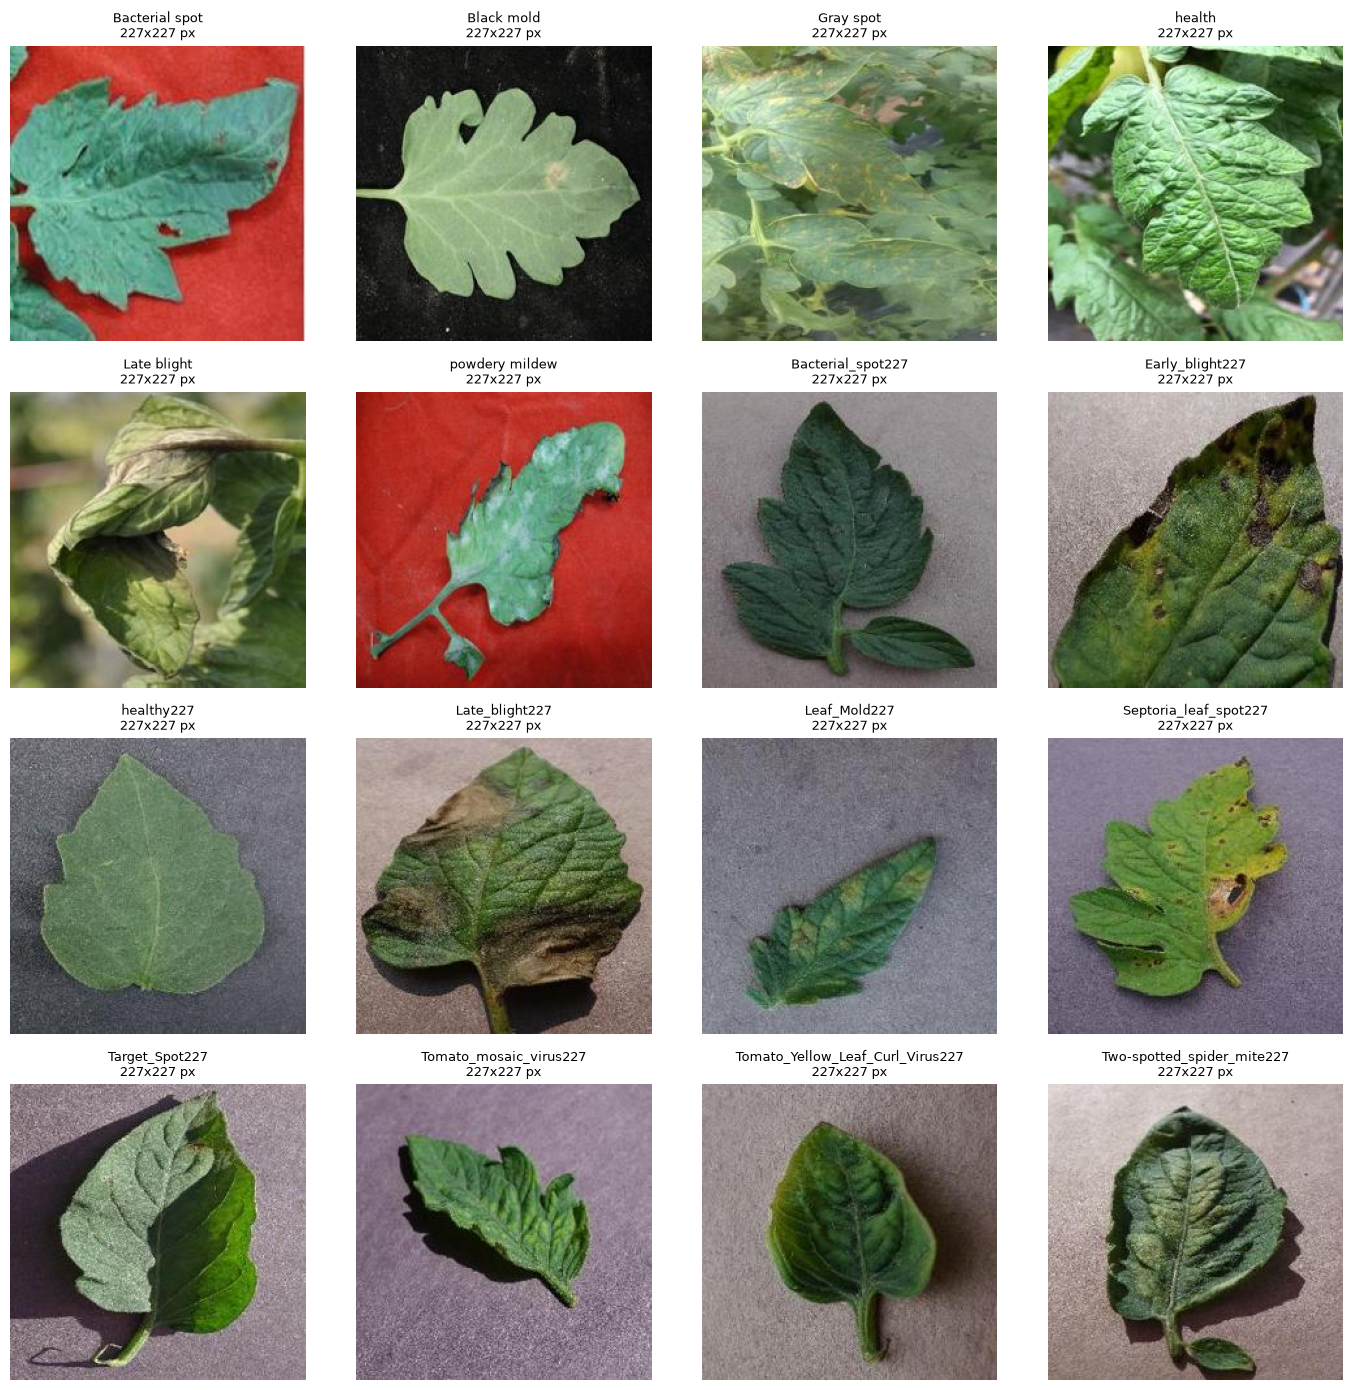

In [7]:
mostrar_grid_por_clase(df_meta)

In [8]:
# Ejecución del resumen
df_categorias = resumir_categorias_dataset('./data')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
display(df_categorias)

,No Preprocesada,Preprocesada,Train,Test,Sin Split,Total_Imagenes
Categoria,,,,,,
Bacterial spot,880,110,792,198,0,990
Bacterial_spot227,8510,1702,6808,1702,1702,10212
Black mold,536,67,481,122,0,603
Early_blight227,4000,800,3200,800,800,4800
Gray spot,672,84,604,152,0,756
Late blight,784,98,705,177,0,882
Late_blight227,7640,1528,6112,1528,1528,9168
Leaf_Mold227,3810,762,3048,762,762,4572
Septoria_leaf_spot227,7085,1417,5668,1417,1417,8502


Confirmamos la hipótesis anterior: Acorde a la documentación existen alrededor de 19 k fotos. Sin embargo, podemos notar que únicamente para `Tomato_Yellow_Leaf_Curl_Virus227`se leen más de 25 k. Leeremos únicamente las fotos de `plantvillage/Preprocessed data` y `taiwan/data augmentation`

<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;"> </span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">3. Transformación</span></div>

 ## Decisiones de transformación
 
1. **Algoritmo de transformación para detección de texturas:** Transformaremos las imágenes a valores numéricos procesables con LBP a través de `skimage.feature.local_binary_pattern` (implementación en Cython, ya optimizada y probada). En lugar de usar el método tradicional, usaremos el método uniforme para LBP, reduciendo el número de características de $2^P$ a $P+2$. Si se desea más información, probaremos a futuro con el método default.
2. **Escalado StandardScaler (para PCA y t-SNE):** se estandarizan los datos (media 0, varianza 1) antes de aplicar PCA y t-SNE como buena práctica para ambos algoritmos. Una vez transformados los datos, evaluaremos de cualquier modo las distribuciones para confirmar su uso.
3. **Escalado MinMaxScaler (para NMF):** Sabemos que NMF requiere valores no negativos, pero también sabemos que es poco probable o imposible obtener un valor negativo de LBP. Una vez transformados los datos, evaluaremos de cualquier modo las distribuciones para confirmar su uso.

In [9]:
def extraer_metadatos_ruta(ruta_img, ruta_base):
    """ 
    Función que resume los metadatos por imagen (indica en qué dataset está, si fue preprocesada,
    si está en algún split o fold, etcétera)

    Args:
        ruta_img (str): Dirección completa de la imagen que permite deducir parte de los metadatos
        ruta_base (str): Dirección de la carpeta origen.

    Returns:
        dict: Metadatos semiestructurados.
    """
    partes = ruta_img.relative_to(ruta_base).parts
    partes_lower = [p.lower() for p in partes]
    dataset = partes[0] if partes else 'desconocido'
    preprocesado = any('preprocessed' in p for p in partes_lower) # Identificamos si se encuentra en un fólder de imágenes preprocesadas
    if 'train' in partes_lower:
        split = 'Train' # Identificamos si se encuentra en un folder de train o test
    elif 'test' in partes_lower:
        split = 'Test'
    else:
        split = 'Sin Split'
    fold = None
    for p in partes:
        m = re.search(r'cross.?validation\D*(\d+)', p, flags=re.IGNORECASE) # Buscamos si se encuentra en algún pliegue de validación cruzada
        if m:
            fold = int(m.group(1))
            break

    categoria = ruta_img.parent.name

    return {
        'dataset': dataset,
        'preprocesado': preprocesado,
        'split': split,
        'fold': fold,
        'categoria': categoria,
    }

def extraer_features_lbp(imagen_gris, P=8, R=1, method='uniform'):
    """
    Calcula el histograma normalizado de Local Binary Patterns de una imagen ya en escala de grises 
    (arreglo 2D). El method='uniform' agrupa los patrones no-uniformes en un solo bin (P+2 bins)

    Args:
        imagen_gris (img): Imagen de PIL despues de aplicar un filtro a gris
        P (int): Vecinos a comparar
        R (int): Radio de comparación
        method (str): Método que LPB va a implementar
    """
    lbp = local_binary_pattern(imagen_gris, P=P, R=R, method=method)
    n_bins = int(lbp.max()) + 1
    hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins))
    hist = hist.astype('float64')
    hist /= (hist.sum() + 1e-7)
    return hist


In [10]:
def cargar_dataset_aplanado(base_dir, nombre_dataset, tam_img=None, P=8, R=1, method='uniform', extensiones=None, mostrar_progreso=True):
    """ 
    Función principal de carga de datos. Carga, convierte a blanco y negro y aplana cada imagen presente en las carpetas, además de recopilar
    información de cada registro según su ruta individual a través de la función anterior.

    Args:
        base_dir (str): Dirección de la carpeta que contiene toda la información
        nombre_dataset (str): Información del dataset de origen
        tam_img (tuple, (227, 227) predeterminado): Resolución deseada. Acorde a la documentación, para la mayoría de las fotos es de 227 x 227
        P (int, 8 default): Parámetro de LBP
        R (int, 1 default): Parámetro de LBP
        method (str, 'uniform' default): Parámetro de LBP
        extensiones (dict, None predeterminado): Tipos de archivos a leer.
        mostrar_progreso (bool, True predeterminado): Para modificar si se muestra el progreso de carga o no
    
    Returns:
        X (np.ndarray): Array con todos los registros aplanados y listos para someter a transformación.
        df_meta (pd.DataFrame): DataFrame con los metadatos de cada registro individual.
    """
    if extensiones is None:
        extensiones = {'.jpg', '.jpeg', '.png', '.bmp'}

    ruta_base = Path(base_dir)
    rutas_img = [p for p in ruta_base.rglob('*') if p.suffix.lower() in extensiones]
    n = len(rutas_img)

    if n == 0:
        raise ValueError(f"No se encontraron imágenes en {base_dir}")

    iterador = rutas_img
    if mostrar_progreso:
        try:
            from tqdm import tqdm
            iterador = tqdm(rutas_img, desc=f'Procesando {nombre_dataset}')
        except ImportError:
            pass

    features = []
    registros = []
    for ruta_img in iterador:
        try:
            with Image.open(ruta_img) as img:
                img_gris = img.convert('L')
                if tam_img is not None:
                    img_gris = img_gris.resize(tam_img, Image.Resampling.LANCZOS)
                arr = np.asarray(img_gris, dtype=np.uint8)

            hist = extraer_features_lbp(arr, P=P, R=R, method=method)
            features.append(hist)

            meta = extraer_metadatos_ruta(ruta_img, ruta_base)
            meta['dataset'] = nombre_dataset
            meta['ruta'] = str(ruta_img)
            registros.append(meta)
        except Exception as e:
            print(f"Imagen omitida por error ({ruta_img}): {e}")

    X = np.array(features, dtype=np.float64)
    df_meta = pd.DataFrame(registros)

    return X, df_meta


In [23]:
X_plantvillage, meta_plantvillage = cargar_dataset_aplanado('./data/plantvillage/Preprocessed data', nombre_dataset='plantvillage', method = 'default')
X_taiwan, meta_taiwan = cargar_dataset_aplanado('./data/taiwan/data augmentation', nombre_dataset='taiwan', method = 'default')

print("PlantVillage: ", X_plantvillage.shape, "-> filas:", len(meta_plantvillage))
print("Taiwan: ", X_taiwan.shape, "-> filas:", len(meta_taiwan))

display(meta_plantvillage.head())
display(meta_taiwan.head())

Procesando taiwan: 100%|██████████| 4976/4976 [01:10<00:00, 70.31it/s]

PlantVillage:  (14531, 256) -> filas: 14531
Taiwan:  (4976, 256) -> filas: 4976


,dataset,preprocesado,split,fold,categoria,ruta
0,plantvillage,False,Sin Split,None,Bacterial_spot227,data\plantvillage\Preprocessed data\Bacterial_...
1,plantvillage,False,Sin Split,None,Bacterial_spot227,data\plantvillage\Preprocessed data\Bacterial_...
2,plantvillage,False,Sin Split,None,Bacterial_spot227,data\plantvillage\Preprocessed data\Bacterial_...
3,plantvillage,False,Sin Split,None,Bacterial_spot227,data\plantvillage\Preprocessed data\Bacterial_...
4,plantvillage,False,Sin Split,None,Bacterial_spot227,data\plantvillage\Preprocessed data\Bacterial_...


,dataset,preprocesado,split,fold,categoria,ruta
0,taiwan,False,Train,None,Bacterial spot,data\taiwan\data augmentation\Train\Bacterial ...
1,taiwan,False,Train,None,Bacterial spot,data\taiwan\data augmentation\Train\Bacterial ...
2,taiwan,False,Train,None,Bacterial spot,data\taiwan\data augmentation\Train\Bacterial ...
3,taiwan,False,Train,None,Bacterial spot,data\taiwan\data augmentation\Train\Bacterial ...
4,taiwan,False,Train,None,Bacterial spot,data\taiwan\data augmentation\Train\Bacterial ...


In [24]:
# Persistir a disco para no repetir el procesamiento cada vez
np.save('X_plantvillage.npy', X_plantvillage)
np.save('X_taiwan.npy', X_taiwan)
meta_plantvillage.to_csv('meta_plantvillage.csv', index = False)
meta_taiwan.to_csv('meta_taiwan.csv', index = False)

In [25]:
X_plantvillage = np.load('X_plantvillage.npy')
X_taiwan = np.load('X_taiwan.npy')
meta_plantvillage = pd.read_csv('meta_plantvillage.csv')
meta_taiwan = pd.read_csv('meta_taiwan.csv')
df_plantvillage = pd.DataFrame(X_plantvillage)
df_plantvillage['categoria'] = meta_plantvillage['categoria'].values
df_taiwan = pd.DataFrame(X_taiwan)
df_taiwan['categoria'] = meta_taiwan['categoria'].values

	PLANTVILLAGE
Número de registros: 14531
Número de columnas: 257
----------------------------------------------------------------------------------------------------
Valores nulos: 0
Valores duplicados: 10
----------------------------------------------------------------------------------------------------
Mostrando boxplots de una muestra aleatoria de 100 de 256 columnas numéricas totales.


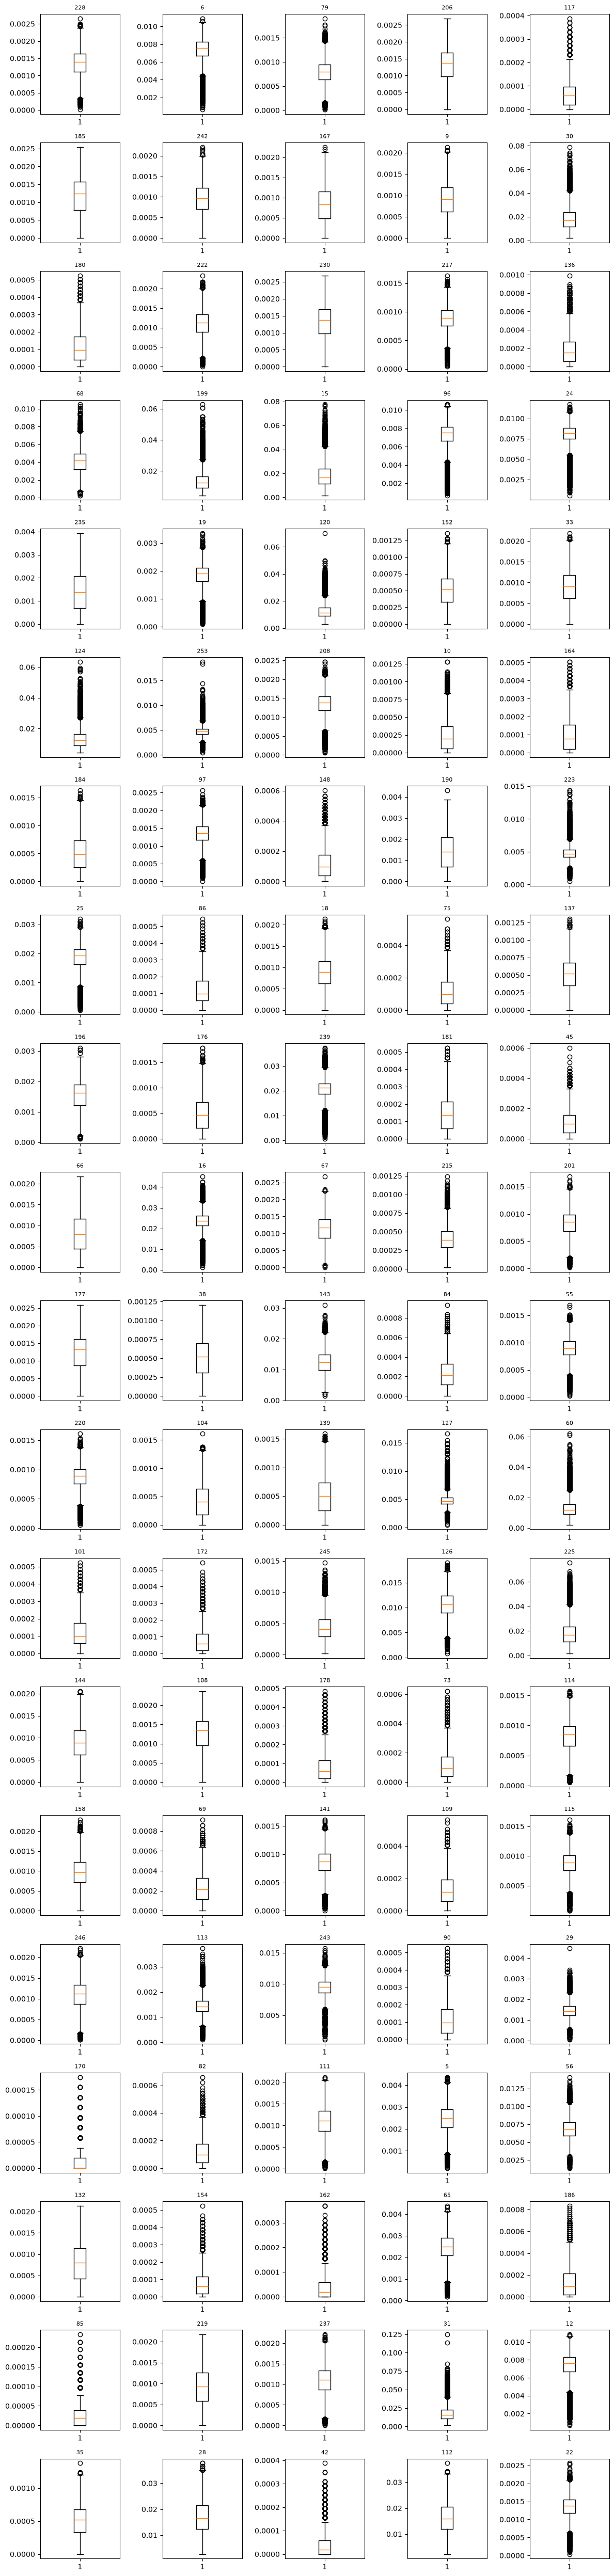

Estadísticas descriptivas:


,228,6,79,206,117,185,242,167,9,30,180,222,230,217,136,68,199,15,96,24,235,19,120,152,33,124,253,208,10,164,184,97,148,190,223,25,86,18,75,137,196,176,239,181,45,66,16,67,215,201,177,38,143,84,55,220,104,139,127,60,101,172,245,126,225,144,108,178,73,114,158,69,141,109,115,246,113,243,90,29,170,82,111,5,56,132,154,162,65,186,85,219,237,31,12,35,28,42,112,22
count,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000,14531.000000
mean,0.001340,0.007230,0.000802,0.001300,0.000063,0.001160,0.000954,0.000825,0.000895,0.019287,0.000109,0.001098,0.001293,0.000884,0.000183,0.004056,0.013918,0.019171,0.007105,0.008028,0.001415,0.001836,0.012886,0.000501,0.000900,0.013794,0.004818,0.001340,0.000236,0.000103,0.000502,0.001339,0.000117,0.001418,0.004911,0.001851,0.000119,0.000883,0.000110,0.000507,0.001532,0.000487,0.020472,0.000138,0.000105,0.000800,0.023422,0.001133,0.000411,0.000817,0.001228,0.000503,0.012589,0.000232,0.000885,0.000873,0.000432,0.000509,0.004868,0.013227,0.000117,0.000079,0.000436,0.010689,0.019122,0.000888,0.001234,0.000077,0.000119,0.000808,0.000956,0.000236,0.000840,0.000130,0.000874,0.001093,0.001475,0.009473,0.000111,0.001479,0.000015,0.000118,0.001089,0.002436,0.006902,0.000790,0.000076,0.000038,0.002440,0.000136,0.000022,0.000921,0.001088,0.018871,0.007249,0.000504,0.017146,0.000038,0.016543,0.001346
std,0.000407,0.001522,0.000228,0.000515,0.000056,0.000537,0.000381,0.000423,0.000385,0.010433,0.000091,0.000355,0.000516,0.000205,0.000156,0.001339,0.006501,0.010506,0.001571,0.001229,0.000860,0.000421,0.005874,0.000238,0.000393,0.006366,0.001007,0.000315,0.000212,0.000090,0.000307,0.000322,0.000097,0.000855,0.001092,0.000426,0.000084,0.000381,0.000091,0.000239,0.000519,0.000316,0.004378,0.000100,0.000085,0.000439,0.004558,0.000384,0.000173,0.000262,0.000511,0.000252,0.003452,0.000143,0.000206,0.000206,0.000288,0.000311,0.001076,0.006034,0.000084,0.000079,0.000200,0.002222,0.010332,0.000387,0.000472,0.000078,0.000098,0.000264,0.000377,0.000144,0.000244,0.000087,0.000205,0.000360,0.000358,0.001340,0.000092,0.000373,0.000025,0.000097,0.000348,0.000655,0.001436,0.000437,0.000077,0.000050,0.000650,0.000135,0.000030,0.000434,0.000361,0.011047,0.001568,0.000240,0.005835,0.000049,0.005489,0.000314
min,0.000019,0.000660,0.000019,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001979,0.000000,0.000000,0.000000,0.000039,0.000000,0.000252,0.004347,0.001669,0.000679,0.000563,0.000000,0.000097,0.003027,0.000000,0.000000,0.004328,0.000427,0.000058,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000485,0.000058,0.000000,0.000000,0.000000,0.000000,0.000116,0.000000,0.000660,0.000000,0.000000,0.000000,0.001145,0.000000,0.000019,0.000019,0.000000,0.000000,0.001417,0.000000,0.000019,0.000058,0.000000,0.000000,

	TAIWAN
Número de registros: 4976
Número de columnas: 257
----------------------------------------------------------------------------------------------------
Valores nulos: 0
Valores duplicados: 0
----------------------------------------------------------------------------------------------------
Mostrando boxplots de una muestra aleatoria de 100 de 256 columnas numéricas totales.


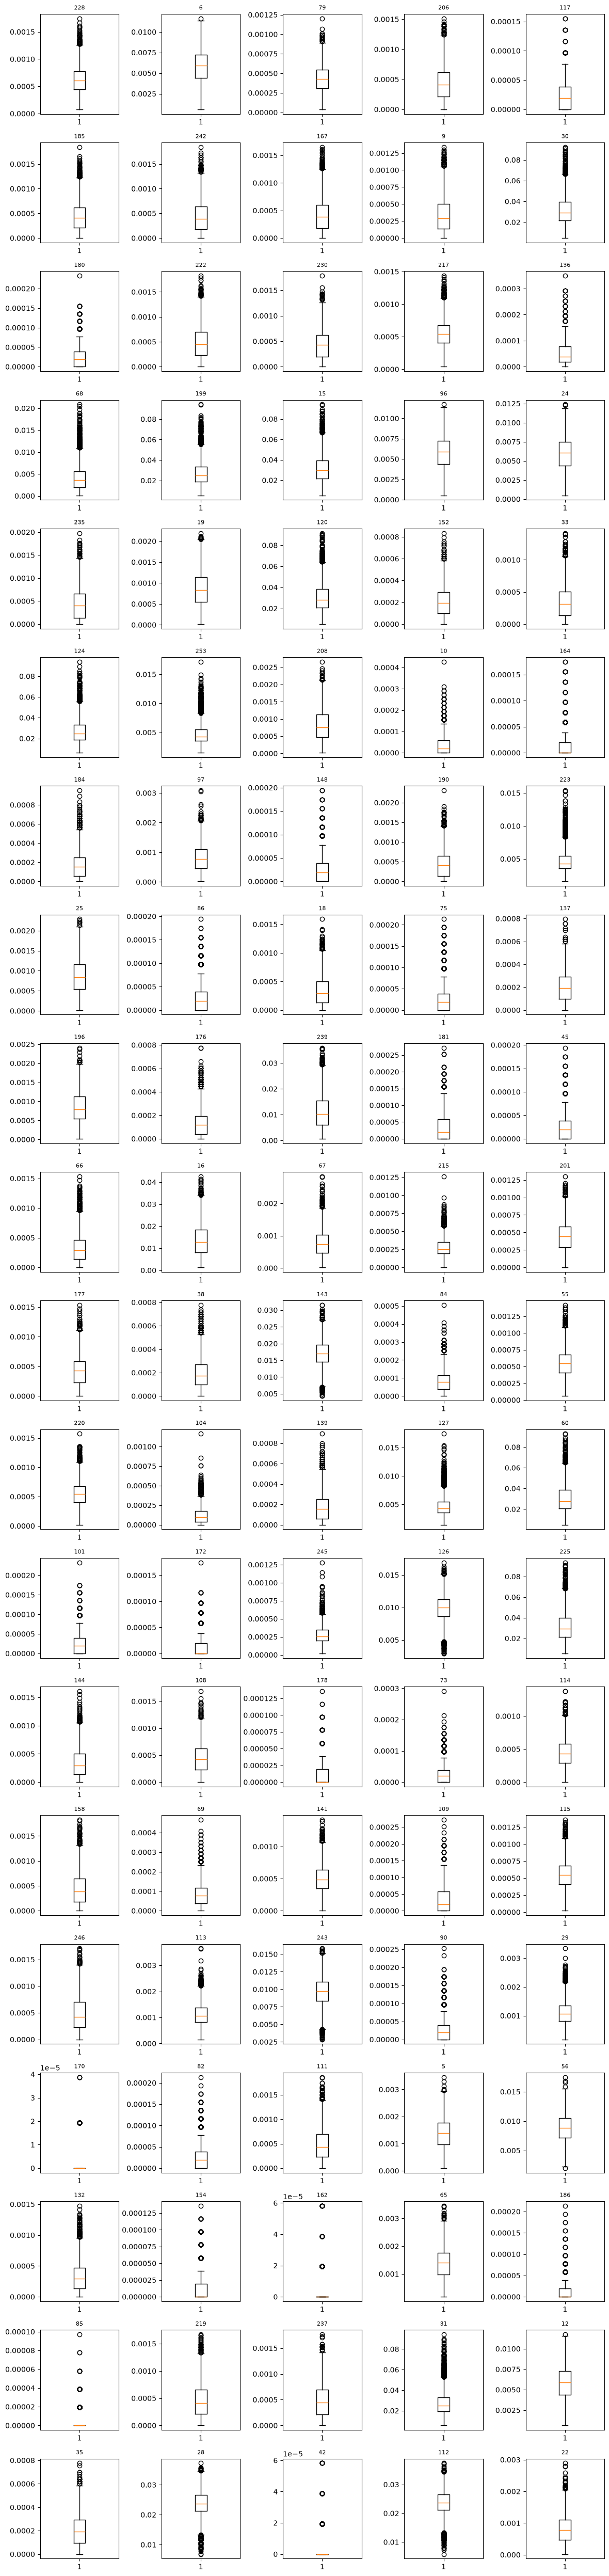

Estadísticas descriptivas:


,228,6,79,206,117,185,242,167,9,30,180,222,230,217,136,68,199,15,96,24,235,19,120,152,33,124,253,208,10,164,184,97,148,190,223,25,86,18,75,137,196,176,239,181,45,66,16,67,215,201,177,38,143,84,55,220,104,139,127,60,101,172,245,126,225,144,108,178,73,114,158,69,141,109,115,246,113,243,90,29,170,82,111,5,56,132,154,162,65,186,85,219,237,31,12,35,28,42,112,22
count,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4.976000e+03,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000
mean,0.000623,0.005823,0.000426,0.000441,0.000021,0.000448,0.000441,0.000418,0.000341,0.031409,0.000021,0.000486,0.000443,0.000554,0.000048,0.004182,0.027352,0.031440,0.005785,0.005916,0.000439,0.000859,0.030496,0.000200,0.000345,0.027331,0.004763,0.000813,0.000037,0.000016,0.000174,0.000813,0.000024,0.000435,0.004761,0.000864,0.000030,0.000340,0.000021,0.000199,0.000845,0.000126,0.011120,0.000032,0.000021,0.000328,0.013710,0.000772,0.000274,0.000449,0.000430,0.000194,0.017061,0.000086,0.000553,0.000554,0.000122,0.000173,0.004720,0.030462,0.000030,0.000008,0.000274,0.009887,0.031589,0.000344,0.000444,0.000008,0.000024,0.000447,0.000442,0.000086,0.000495,0.000033,0.000552,0.000486,0.001119,0.009676,0.000021,0.001107,3.666028e-07,0.000024,0.000484,0.001378,0.008807,0.000325,0.000008,0.000002,0.001379,0.000012,0.000004,0.000459,0.000483,0.027557,0.005812,0.000200,0.023825,0.000002,0.023752,0.000817
std,0.000253,0.001997,0.000166,0.000280,0.000022,0.000289,0.000316,0.000295,0.000249,0.013311,0.000027,0.000318,0.000283,0.000208,0.000046,0.002836,0.011474,0.013274,0.002019,0.002084,0.000329,0.000407,0.013215,0.000129,0.000253,0.011551,0.001805,0.000431,0.000043,0.000024,0.000136,0.000429,0.000028,0.000330,0.001792,0.000411,0.000030,0.000247,0.000028,0.000127,0.000395,0.000107,0.006119,0.000035,0.000028,0.000240,0.006873,0.000400,0.000125,0.000214,0.000250,0.000127,0.003904,0.000058,0.000207,0.000208,0.000104,0.000135,0.001774,0.013150,0.000029,0.000015,0.000125,0.002016,0.013586,0.000252,0.000262,0.000015,0.000028,0.000211,0.000319,0.000057,0.000219,0.000036,0.000207,0.000315,0.000418,0.002009,0.000029,0.000414,2.754471e-06,0.000029,0.000314,0.000529,0.002371,0.000237,0.000015,0.000007,0.000533,0.000021,0.000009,0.000300,0.000313,0.011537,0.002031,0.000127,0.004095,0.000007,0.004084,0.000432
min,0.000078,0.000602,0.000039,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.004716,0.000000,0.000000,0.000000,0.000039,0.000000,0.000116,0.005376,0.005104,0.000524,0.000485,0.000000,0.000019,0.005143,0.000000,0.000000,0.006288,0.001494,0.000019,0.000000,0.000000,0.000000,0.000019,0.000000,0.000000,0.001591,0.000019,0.000000,0.000000,0.000000,0.000000,0.000019,0.000000,0.000660,0.000000,0.000000,0.000000,0.001300,0.000019,0.000000,0.000000,0.000000,0.000000,0.004308,0.000000,0.000058,0.000019,0.000000,0.000000,0.001417,0.004910,0.000000,0.000000,0.000019,0.002930,0.005337,0.000000,0.000000,0.000000,0

In [26]:
def perfilado_general_muestra(df, n_muestra=30, random_state=42):
    """
    Genera un perfilado exploratorio de un DataFrame de alta dimensionalidad,
    mostrando boxplots de una muestra aleatoria de columnas numéricas.

    Args:
        df (pd.DataFrame): DataFrame a perfilar 
        n_muestra (int): número de columnas numéricas a graficar en los
            boxplots. Default 30.
        random_state (int): semilla para la selección aleatoria de columnas,
            para reproducibilidad.

    Returns:
        None: la función imprime y despliega los resultados directamente
        (no retorna ningún objeto).
    """
    n, m = df.shape
    print(f'Número de registros: {n}')
    print(f'Número de columnas: {m}')
    print('-' * 100)
    print(f'Valores nulos: {df.isna().sum().sum()}')
    print(f'Valores duplicados: {df.duplicated().sum()}')
    print('-' * 100)

    cols_numericas = df.select_dtypes(include=('float64', 'int64')).columns
    cols_muestra = pd.Series(cols_numericas).sample(
        n=min(n_muestra, len(cols_numericas)), random_state=random_state
    )

    print(f'Mostrando boxplots de una muestra aleatoria de {len(cols_muestra)} '
          f'de {len(cols_numericas)} columnas numéricas totales.')

    col_num = len(cols_muestra)
    plt.figure(figsize=(12, mt.ceil(col_num / 5) * 2.5))
    for i, column in enumerate(cols_muestra):
        plt.subplot(mt.ceil(col_num / 5), 5, i + 1)
        plt.boxplot(df[column])
        plt.title(column, fontsize=8)
    plt.tight_layout()
    plt.show()

    print('Estadísticas descriptivas:')
    display(df[cols_muestra].describe())

print('\tPLANTVILLAGE')
perfilado_general_muestra(df_plantvillage, n_muestra= 100)
print('\tTAIWAN')
perfilado_general_muestra(df_taiwan, n_muestra= 100)

Claramente es necesario efectuar un escalado: Evaluando los boxplot, existe una gran cantidad de valores atípicos.

In [27]:
y_plantvillage = np.array(meta_plantvillage['categoria'].values)
y_taiwan = np.array(meta_taiwan['categoria'].values)

X_train_plant, X_test_plant, y_train_plant, y_test_plant = train_test_split(X_plantvillage, y_plantvillage, test_size=0.25, random_state=42)

X_train_taiwan, X_test_taiwan, y_train_taiwan, y_test_taiwan = train_test_split(X_taiwan, y_taiwan, test_size=0.25, random_state=42)

scaler_std_1 = StandardScaler()
scaler_std_1.fit(X_train_plant)
X_train_plant_std = scaler_std_1.transform(X_train_plant)
X_test_plant_std = scaler_std_1.transform(X_test_plant)
scaler_std_2 = StandardScaler()
scaler_std_2.fit(X_train_taiwan)
X_train_taiwan_std = scaler_std_2.transform(X_train_taiwan)
X_test_taiwan_std = scaler_std_2.transform(X_test_taiwan)

scaler_mm_1 = MinMaxScaler()
scaler_mm_1.fit(X_train_plant)
X_train_plant_mm = scaler_mm_1.transform(X_train_plant)
X_test_plant_mm = scaler_mm_1.transform(X_test_plant)
scaler_mm_2 = MinMaxScaler()
scaler_mm_2.fit(X_train_taiwan)
X_train_taiwan_mm = scaler_mm_2.transform(X_train_taiwan)
X_test_taiwan_mm = scaler_mm_2.transform(X_test_taiwan)

<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;"></span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">4. Aplicación de Algoritmos </span></div>

### PCA

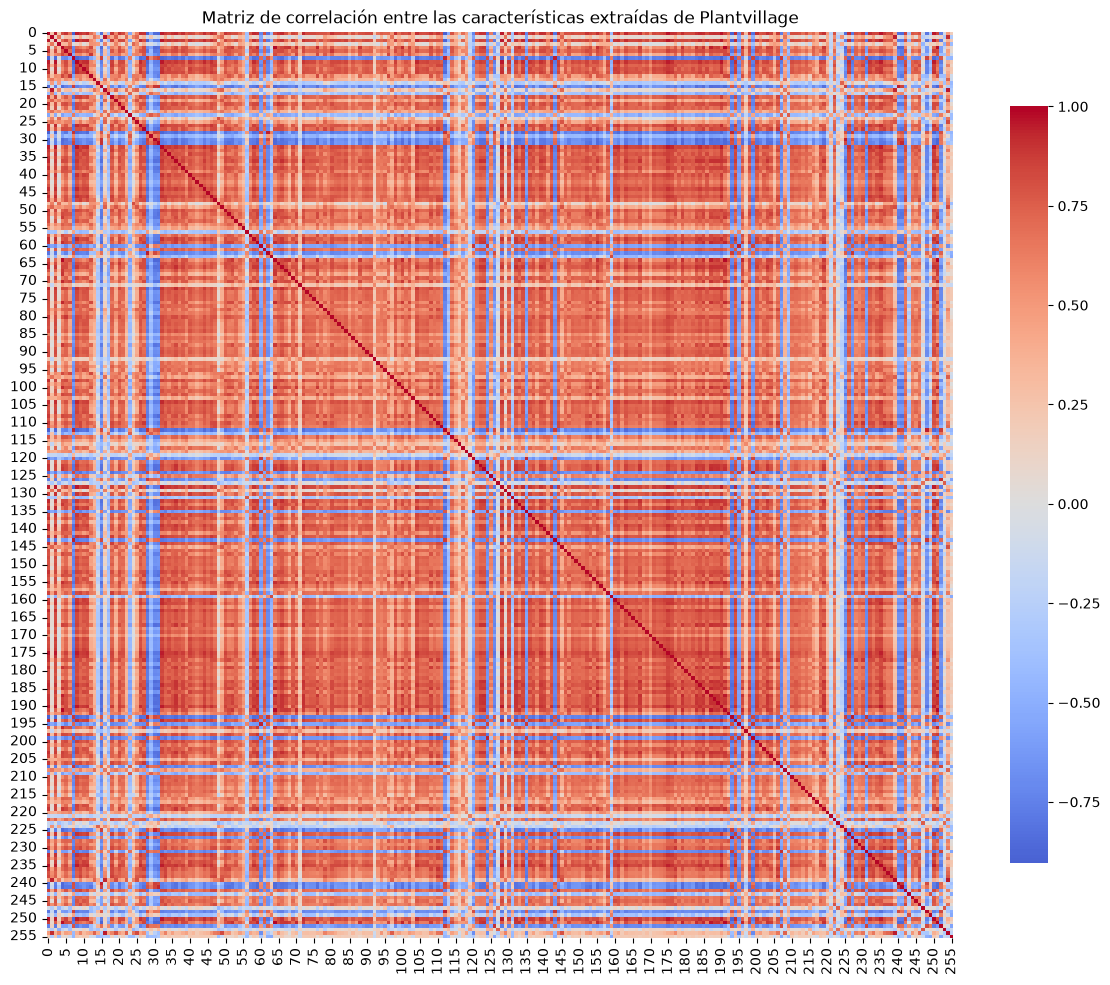

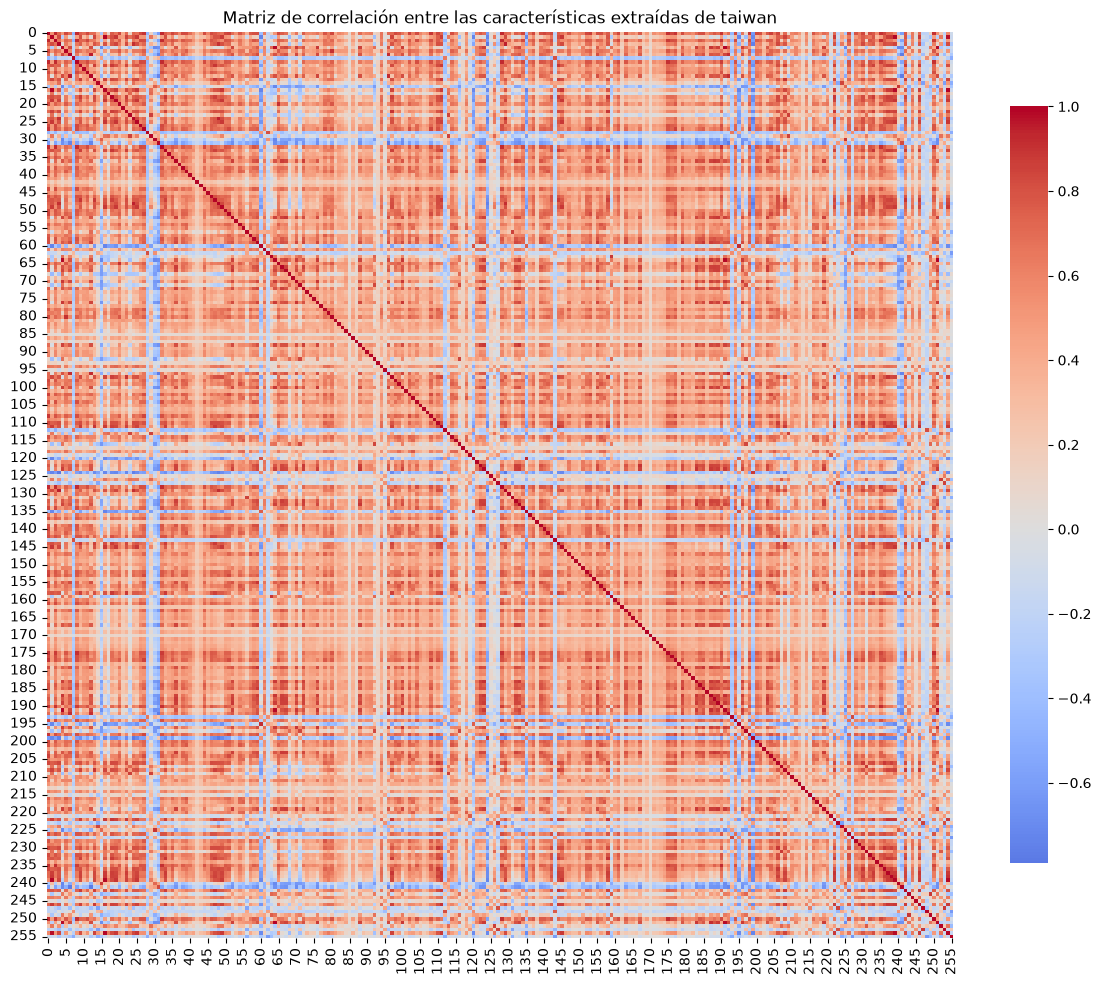

In [28]:
#Matriz de correlación para PCA 
plt.figure(figsize=(12, 10))
matriz_corr = df_plantvillage.select_dtypes(include = 'float').corr()
sns.heatmap(matriz_corr, cmap='coolwarm', center=0, square=True, cbar_kws={'shrink': 0.8})
plt.tight_layout()
plt.title('Matriz de correlación entre las características extraídas de Plantvillage')
plt.show()

plt.figure(figsize=(12, 10))
matriz_corr = df_taiwan.select_dtypes(include = 'float').corr()
sns.heatmap(matriz_corr, cmap='coolwarm', center=0, square=True, cbar_kws={'shrink': 0.8})
plt.tight_layout()
plt.title('Matriz de correlación entre las características extraídas de taiwan')
plt.show()

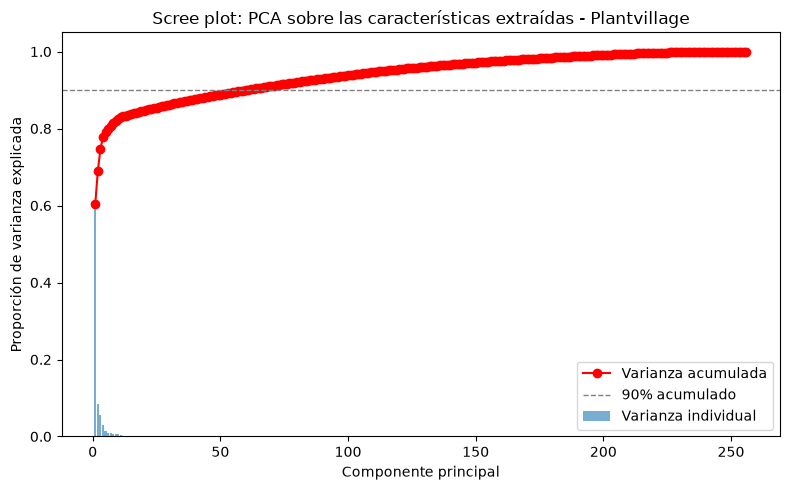


Primeros eigenvalores: [0.60484268 0.08508624 0.05666596 0.03029308 0.01440588]
Acumulada de los primeros eigenvalores: [0.60484268 0.68992892 0.74659489 0.77688797 0.79129385]



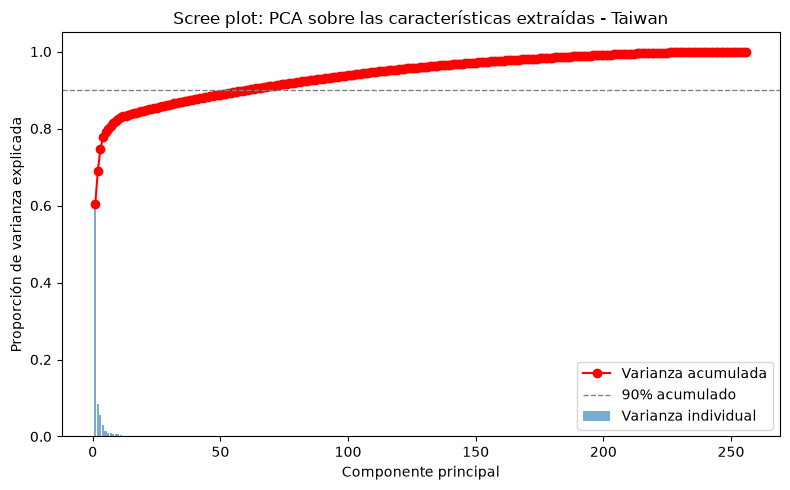


Primeros eigenvalores: [0.60484268 0.08508624 0.05666596 0.03029308 0.01440588]
Acumulada de los primeros eigenvalores: [0.60484268 0.68992892 0.74659489 0.77688797 0.79129385]


In [ ]:
pca_plant = PCA()
pca_plant.fit(X_train_plant_std)

varianza_explicada = pca_plant.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

plt.figure(figsize=(8, 5))
plt.bar(range(1, len(varianza_explicada) + 1), varianza_explicada, alpha=0.6, label='Varianza individual')
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', color='red', label='Varianza acumulada')
plt.axhline(0.9, color='gray', linestyle='--', linewidth=1, label='90% acumulado')
plt.xlabel('Componente principal')
plt.ylabel('Proporción de varianza explicada')
plt.title('Scree plot: PCA sobre las características extraídas - Plantvillage')
plt.legend()
plt.tight_layout()
plt.show()

print(f'\nPrimeros eigenvalores: {varianza_explicada[:5]}')
print(f'Acumulada de los primeros eigenvalores: {varianza_acumulada[:5]}\n')

pca_taiwan = PCA()
pca_taiwan.fit(X_train_taiwan_std)

varianza_explicada = pca_plant.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

plt.figure(figsize=(8, 5))
plt.bar(range(1, len(varianza_explicada) + 1), varianza_explicada, alpha=0.6, label='Varianza individual')
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', color='red', label='Varianza acumulada')
plt.axhline(0.9, color='gray', linestyle='--', linewidth=1, label='90% acumulado')
plt.xlabel('Componente principal')
plt.ylabel('Proporción de varianza explicada')
plt.title('Scree plot: PCA sobre las características extraídas - Taiwan')
plt.legend()
plt.tight_layout()
plt.show()

print(f'\nPrimeros eigenvalores: {varianza_explicada[:5]}')
print(f'Acumulada de los primeros eigenvalores: {varianza_acumulada[:5]}')

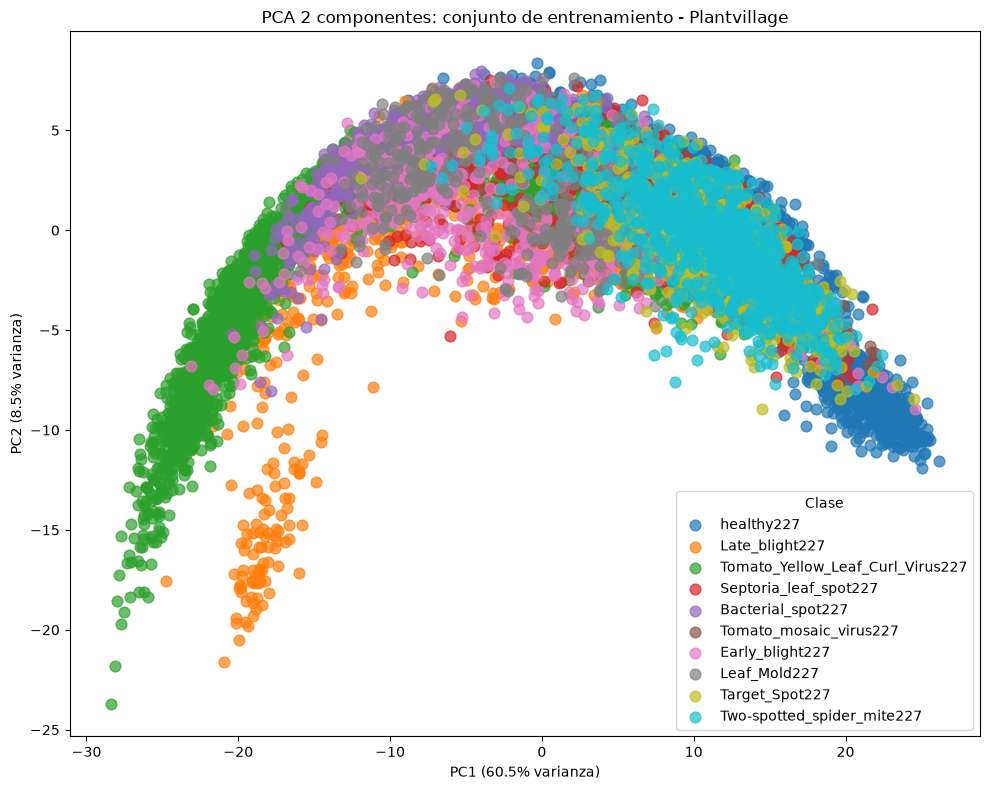

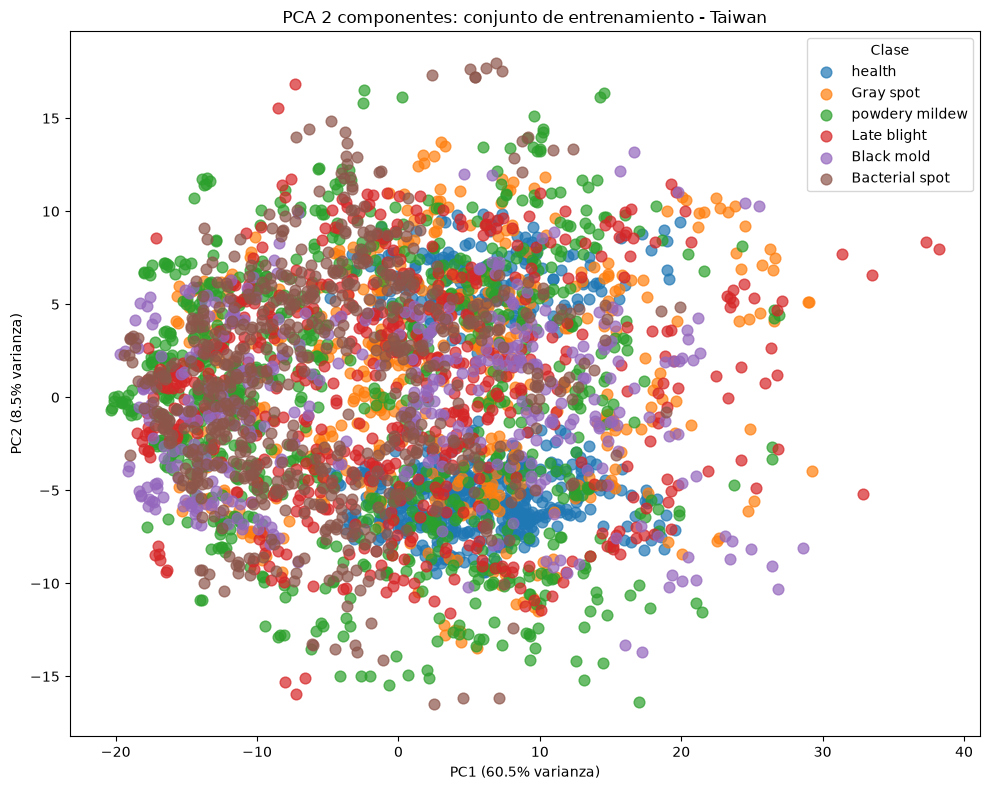

In [36]:
# PCA con 2 componentes, visualización a detalle
pca_plant_2 = PCA(n_components=2)
X_pca_plant_2 = pca_plant_2.fit_transform(X_train_plant_std)
df_pca_plant_2 = pd.DataFrame(X_pca_plant_2, columns=['PC1', 'PC2'])
df_pca_plant_2['categoria'] = y_train_plant

plt.figure(figsize=(10, 8))
for clase in df_pca_plant_2['categoria'].unique():
    subset = df_pca_plant_2[df_pca_plant_2['categoria'] == clase]
    plt.scatter(subset['PC1'], subset['PC2'], label=clase, alpha=0.7, s=60)

plt.xlabel(f'PC1 ({pca_plant_2.explained_variance_ratio_[0]*100:.1f}% varianza)')
plt.ylabel(f'PC2 ({pca_plant_2.explained_variance_ratio_[1]*100:.1f}% varianza)')
plt.title('PCA 2 componentes: conjunto de entrenamiento - Plantvillage')
plt.legend(title='Clase')
plt.tight_layout()
plt.show()

pca_taiwan_2 = PCA(n_components=2)
X_pca_taiwan_2 = pca_taiwan_2.fit_transform(X_train_taiwan_std)

df_pca_taiwan_2 = pd.DataFrame(X_pca_taiwan_2, columns=['PC1', 'PC2'])
df_pca_taiwan_2['categoria'] = y_train_taiwan

plt.figure(figsize=(10, 8))
for clase in df_pca_taiwan_2['categoria'].unique():
    subset = df_pca_taiwan_2[df_pca_taiwan_2['categoria'] == clase]
    plt.scatter(subset['PC1'], subset['PC2'], label=clase, alpha=0.7, s=60)

plt.xlabel(f'PC1 ({pca_plant_2.explained_variance_ratio_[0]*100:.1f}% varianza)')
plt.ylabel(f'PC2 ({pca_plant_2.explained_variance_ratio_[1]*100:.1f}% varianza)')
plt.title('PCA 2 componentes: conjunto de entrenamiento - Taiwan')
plt.legend(title='Clase')
plt.tight_layout()
plt.show()

In [37]:
# PCA con 3 componentes, visualización a detalle
pca_plant_3 = PCA(n_components=3)
X_pca_plant_3 = pca_plant_3.fit_transform(X_train_plant_std)

df_pca_plant_3 = pd.DataFrame(X_pca_plant_3, columns=['PC1', 'PC2', 'PC3'])
df_pca_plant_3['categoria'] = y_train_plant

fig = px.scatter_3d(
    df_pca_plant_3, x='PC1', y='PC2', z='PC3', color='categoria',
    title='PCA 3 componentes: conjunto de entrenamiento - Plantvillage'
)
fig.show()

pca_taiwan_3 = PCA(n_components=3)
X_pca_taiwan_3 = pca_taiwan_3.fit_transform(X_train_taiwan_std)

df_pca_taiwan_3 = pd.DataFrame(X_pca_taiwan_3, columns=['PC1', 'PC2', 'PC3'])
df_pca_taiwan_3['categoria'] = y_train_taiwan

fig = px.scatter_3d(
    df_pca_taiwan_3, x='PC1', y='PC2', z='PC3', color='categoria',
    title='PCA 3 componentes: conjunto de entrenamiento - Taiwan'
)
fig.show()

<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;"></span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">5. Clasificadores </span></div>

In [46]:
# PCA con componentes ideales
pca_plant = PCA(n_components = 0.9)
X_pca_plant = pca_plant.fit_transform(X_train_plant_std)
X_test_pca_plant = pca_plant.transform(X_test_plant_std)
print(f'Se retuvieron {X_pca_plant.shape[1]} componentes para Plantvillage')

pca_taiwan = PCA(n_components = 0.9)
X_pca_taiwan = pca_taiwan.fit_transform(X_train_taiwan_std)
X_test_pca_taiwan = pca_taiwan.transform(X_test_taiwan_std)
print(f'Se retuvieron {X_pca_taiwan.shape[1]} componentes para Taiwan')

def entrenar_svm_rbf(X_train, y_train, X_test, y_test, nombre_dataset, param_grid=None, cv=5):
    """
    Hace GridSearchCV de un SVM-RBF sobre (X, y) y reentrena el mejor estimador.

    Args
        X (array): De tamaño (n_muestras, n_componentes_pca)
        y (array): Series de etiquetas (categoría)
        nombre_dataset (str): Solo para los prints
        param_grid (dict, None default): grilla de C/gamma, si es None usa una por default
        cv (int, 5 default): folds para la validación cruzada del GridSearch

    Returns
        modelo_final: mejor SVC ya entrenado
        grid: objeto GridSearchCV completo 
    """
    if param_grid is None:
        param_grid = {
            'C': [0.1, 1, 10, 100],
            'gamma': ['scale', 0.01, 0.001, 0.0001],
        }

    grid = GridSearchCV(
        estimator = SVC(kernel='rbf', class_weight='balanced'),
        param_grid = param_grid,
        cv = cv,
        scoring = 'f1_macro',
        n_jobs = -1,
        verbose = 1,
    )
    grid.fit(X_train, y_train)

    print(f"[{nombre_dataset}] Mejores parámetros: {grid.best_params_}")
    print(f"[{nombre_dataset}] Mejor f1_macro (CV): {grid.best_score_:.4f}")

    modelo_final = grid.best_estimator_
    y_pred = modelo_final.predict(X_test)

    print(f"\n\t{nombre_dataset.upper()}: reporte en test")
    print(classification_report(y_test, y_pred))

    return modelo_final, grid

Se retuvieron 61 componentes para Plantvillage
Se retuvieron 77 componentes para Taiwan


In [41]:
modelo_plant, grid_plant = entrenar_svm_rbf(X_pca_plant, y_train_plant, X_test_pca_plant, y_test_plant, 'plantvillage')
modelo_taiwan, grid_taiwan = entrenar_svm_rbf(X_pca_taiwan, y_train_taiwan, X_test_pca_taiwan, y_test_taiwan, 'taiwan')

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[plantvillage] Mejores parámetros: {'C': 10, 'gamma': 0.01}
[plantvillage] Mejor f1_macro (CV): 0.5752

	PLANTVILLAGE: reporte en test
                                  precision    recall  f1-score   support

               Bacterial_spot227       0.69      0.84      0.75       434
                 Early_blight227       0.44      0.54      0.49       202
                  Late_blight227       0.64      0.59      0.61       391
                    Leaf_Mold227       0.56      0.51      0.53       182
           Septoria_leaf_spot227       0.41      0.46      0.44       363
                  Target_Spot227       0.49      0.46      0.47       281
Tomato_Yellow_Leaf_Curl_Virus227       0.89      0.81      0.85      1053
          Tomato_mosaic_virus227       0.34      0.18      0.24        94
      Two-spotted_spider_mite227       0.52      0.54      0.53       332
                      healthy227       0.85      0.90      0.88

<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;"></span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">6. Conclusiones </span></div>